# Interactive Local Orthogonal Coordinate Transform (OCT) Explorer

This notebook allows you to interactively explore how the parameters of a LocalOCT affect the resulting coordinate grid.

## Parameters and Constraints

A LocalOCT in 2D is parameterized by:
- **p**: Base point (we fix at origin)
- **U**: Orthonormal frame - parameterized by rotation angle θ
- **log_s**: Log of loadings (s₁, s₂) - 2 free parameters
- **β**: Rotation coefficients - **symmetric** matrix, so only 3 free params (β₁₁, β₁₂=β₂₁, β₂₂)
- **dβ**: Computed from β via Lamé equations (flatness constraints)

### Geometric Interpretation
- **θ**: Rotation of the principal directions
- **log_s**: How stretched/compressed each coordinate direction is
- **β_ii**: Score coefficients - affect log-likelihood gradients
- **β_ij (i≠j)**: Rotation coefficients - control how coordinate curves bend


In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, FloatText, FloatSlider, VBox, HBox, Label, Output, Button
import ipywidgets as widgets
from IPython.display import display, clear_output

# Add the local_coordinates package to path
import sys
sys.path.insert(0, '..')

from local_coordinates.oct import LocalOCT, plot_oct_grid, _compute_dbeta_from_beta


In [2]:
def create_orthonormal_U(theta: float) -> jnp.ndarray:
    """Create a 2x2 orthonormal matrix from rotation angle theta."""
    c, s = jnp.cos(theta), jnp.sin(theta)
    return jnp.array([[c, -s], [s, c]])

def create_beta(beta_11: float, beta_12: float, beta_21: float, beta_22: float, enforce_symmetry: bool = True) -> jnp.ndarray:
    """Create a 2x2 beta matrix, optionally enforcing symmetry."""
    if enforce_symmetry:
        # Use beta_12 for both off-diagonal entries
        return jnp.array([[beta_11, beta_12], [beta_12, beta_22]])
    else:
        # Allow asymmetric beta
        return jnp.array([[beta_11, beta_12], [beta_21, beta_22]])

def create_oct_from_params(theta, log_s1, log_s2, beta_11, beta_12, beta_21, beta_22, enforce_symmetry=True):
    """Create a LocalOCT from the UI parameters."""
    p = jnp.zeros(2)
    U = create_orthonormal_U(theta)
    log_s = jnp.array([log_s1, log_s2])
    beta = create_beta(beta_11, beta_12, beta_21, beta_22, enforce_symmetry)
    dbeta = _compute_dbeta_from_beta(beta)

    return LocalOCT(p=p, U=U, log_s=log_s, beta=beta, dbeta=dbeta)


In [8]:
# Create the output area for the plot
output = Output()

# Create slider widgets for each parameter (continuous update while dragging)
style = {'description_width': '120px'}
layout = widgets.Layout(width='350px')

# Principal basis angle
theta_widget = FloatSlider(
    value=0.0,
    min=-jnp.pi,
    max=jnp.pi,
    step=0.05,
    description='θ (radians):',
    style=style,
    layout=layout,
    continuous_update=True,
    readout_format='.2f'
)

# Log loadings
log_s1_widget = FloatSlider(
    value=0.0,
    min=-10.0,
    max=2.0,
    step=0.05,
    description='log(s1):',
    style=style,
    layout=layout,
    continuous_update=True,
    readout_format='.2f'
)

log_s2_widget = FloatSlider(
    value=0.0,
    min=-10.0,
    max=2.0,
    step=0.05,
    description='log(s2):',
    style=style,
    layout=layout,
    continuous_update=True,
    readout_format='.2f'
)

# Beta matrix widgets
beta_11_widget = FloatSlider(
    value=0.0,
    min=-7.0,
    max=7.0,
    step=0.1,
    description='β11:',
    style=style,
    layout=layout,
    continuous_update=True,
    readout_format='.2f'
)

beta_12_widget = FloatSlider(
    value=0.0,
    min=-7.0,
    max=7.0,
    step=0.1,
    description='β12:',
    style=style,
    layout=layout,
    continuous_update=True,
    readout_format='.2f'
)

# Separate beta_21 widget (only used when symmetry is not enforced)
beta_21_widget = FloatSlider(
    value=0.0,
    min=-7.0,
    max=7.0,
    step=0.1,
    description='β21:',
    style=style,
    layout=layout,
    continuous_update=True,
    readout_format='.2f'
)

beta_22_widget = FloatSlider(
    value=0.0,
    min=-7.0,
    max=7.0,
    step=0.1,
    description='β22:',
    style=style,
    layout=layout,
    continuous_update=True,
    readout_format='.2f'
)

# Symmetry enforcement toggle
symmetry_toggle = widgets.Checkbox(
    value=True,
    description='Enforce β symmetry (β12 = β21)',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

# Grid parameters
span_widget = FloatSlider(
    value=0.3,
    min=0.1,
    max=1.0,
    step=0.05,
    description='Grid span:',
    style=style,
    layout=layout,
    continuous_update=True,
    readout_format='.2f'
)

# Toggle for showing coordinate grid
show_grid_toggle = widgets.Checkbox(
    value=True,
    description='Show coordinate grid',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

# Toggle for showing arrows (basis vectors)
show_arrows_toggle = widgets.Checkbox(
    value=True,
    description='Show basis vectors',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

# Toggle for showing samples
show_samples_toggle = widgets.Checkbox(
    value=False,
    description='Show Gaussian samples',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

# Gaussian standard deviation slider
sample_std_widget = FloatSlider(
    value=0.1,
    min=0.01,
    max=0.5,
    step=0.01,
    description='Sample σ:',
    style=style,
    layout=layout,
    continuous_update=True,
    readout_format='.3f'
)

# Number of samples slider
n_samples_widget = widgets.IntSlider(
    value=500,
    min=100,
    max=2000,
    step=100,
    description='N samples:',
    style=style,
    layout=layout,
    continuous_update=True
)

# Function to show/hide sample controls
def on_samples_toggle_change(change):
    if change['new']:
        sample_std_widget.layout.display = ''
        n_samples_widget.layout.display = ''
    else:
        sample_std_widget.layout.display = 'none'
        n_samples_widget.layout.display = 'none'

show_samples_toggle.observe(on_samples_toggle_change, names='value')

# Initially hide sample controls
sample_std_widget.layout.display = 'none'
n_samples_widget.layout.display = 'none'

# Update button (optional manual refresh)
update_button = Button(description='Update Plot', button_style='primary')

# Function to show/hide beta_21 based on symmetry toggle
def on_symmetry_change(change):
    # Ensure all other beta widgets stay visible
    beta_11_widget.layout.display = ''
    beta_12_widget.layout.display = ''
    beta_22_widget.layout.display = ''

    if change['new']:
        # Symmetry enforced: hide beta_21, sync its value
        beta_21_widget.layout.display = 'none'
        beta_21_widget.value = beta_12_widget.value
    else:
        # Symmetry not enforced: show beta_21
        beta_21_widget.layout.display = ''

symmetry_toggle.observe(on_symmetry_change, names='value')

# Also sync beta_21 to beta_12 when symmetry is enforced
def sync_beta_21(change):
    if symmetry_toggle.value:
        beta_21_widget.value = beta_12_widget.value

beta_12_widget.observe(sync_beta_21, names='value')

# Ensure all widgets are visible by default
for w in [theta_widget, log_s1_widget, log_s2_widget,
          beta_11_widget, beta_12_widget, beta_22_widget,
          span_widget, update_button, symmetry_toggle,
          show_grid_toggle, show_arrows_toggle, show_samples_toggle]:
    w.layout.display = ''

# Only hide beta_21 since symmetry is enforced by default
beta_21_widget.layout.display = 'none'

# Hide sample controls by default (shown when samples toggle is checked)
sample_std_widget.layout.display = 'none'
n_samples_widget.layout.display = 'none'


In [9]:
from jax import random
from local_coordinates.jet import Jet

def map_z_to_x(oct, z_samples):
    """Map points from z-space to x-space using the OCT's Taylor expansion."""
    jacobian = oct.get_jacobian()
    jet = Jet(
        value=oct.p,
        gradient=jacobian.value,
        hessian=jacobian.gradient,
    )
    # Evaluate the jet at each sample point
    x_samples = jax.vmap(lambda z: jet(z))(z_samples)
    return x_samples

def update_plot(b=None):
    """Update the plot with current widget values."""
    with output:
        clear_output(wait=True)

        # Get current values
        theta = theta_widget.value
        log_s1 = log_s1_widget.value
        log_s2 = log_s2_widget.value
        beta_11 = beta_11_widget.value
        beta_12 = beta_12_widget.value
        beta_21 = beta_21_widget.value
        beta_22 = beta_22_widget.value
        span = span_widget.value
        enforce_symmetry = symmetry_toggle.value
        show_grid = show_grid_toggle.value
        show_arrows = show_arrows_toggle.value
        show_samples = show_samples_toggle.value
        sample_std = sample_std_widget.value
        n_samples = n_samples_widget.value

        # Create the OCT
        try:
            oct = create_oct_from_params(
                theta, log_s1, log_s2,
                beta_11, beta_12, beta_21, beta_22,
                enforce_symmetry=enforce_symmetry
            )

            # Create figure
            fig, ax = plt.subplots(figsize=(8, 8))

            # Build title showing mode
            sym_str = "symmetric β" if enforce_symmetry else "non-symmetric β"
            parts = []
            if show_grid:
                parts.append("Grid")
            if show_arrows:
                parts.append("Arrows")
            if show_samples:
                parts.append(f"Samples N(0, {sample_std:.2f}²)")
            if parts:
                title = f'{" + ".join(parts)} ({sym_str})'
            else:
                title = f'Empty plot ({sym_str})'

            # Plot the coordinate grid
            plot_oct_grid(
                oct,
                num=21,
                span=span,
                show=False,
                ax=ax,
                title=title,
                draw_grid=show_grid,
                draw_basis_vectors=show_arrows
            )

            # If showing samples, draw them on top
            if show_samples:
                # Generate samples from Gaussian in z-space
                key = random.PRNGKey(42)  # Fixed seed for reproducibility
                z_samples = random.normal(key, shape=(n_samples, 2)) * sample_std

                # Map to x-space
                x_samples = map_z_to_x(oct, z_samples)

                # Plot samples
                ax.scatter(
                    x_samples[:, 0], x_samples[:, 1],
                    c='#F4A024',  # Orange/gold color
                    s=8,
                    alpha=0.7,
                    edgecolors='#1a1a2e',
                    linewidths=0.3,
                    zorder=20
                )

            plt.tight_layout()
            plt.show()

        except Exception as e:
            import traceback
            traceback.print_exc()

# Connect button to update function
update_button.on_click(update_plot)

# Also update on value change for each widget
for w in [theta_widget, log_s1_widget, log_s2_widget,
          beta_11_widget, beta_12_widget, beta_21_widget, beta_22_widget,
          span_widget, symmetry_toggle, show_grid_toggle, show_arrows_toggle,
          show_samples_toggle, sample_std_widget, n_samples_widget]:
    w.observe(lambda change: update_plot(), names='value')


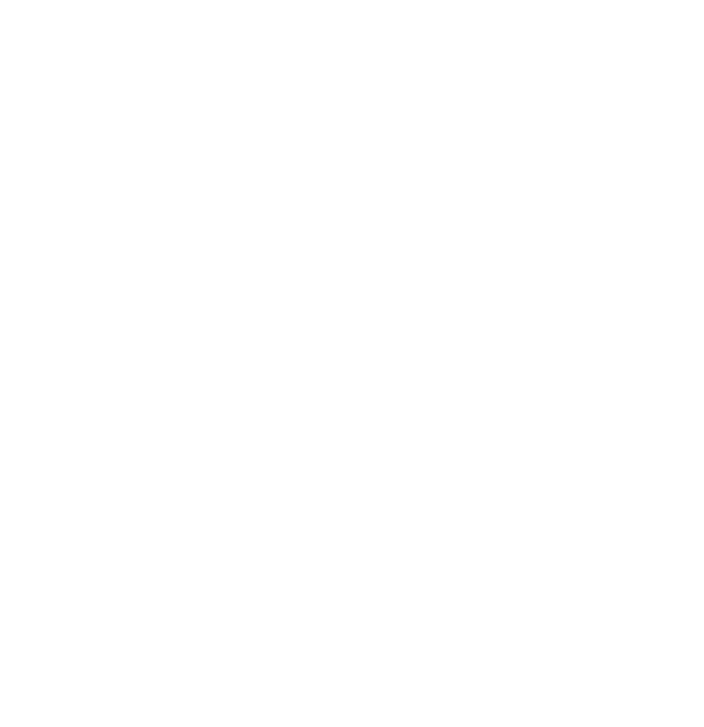

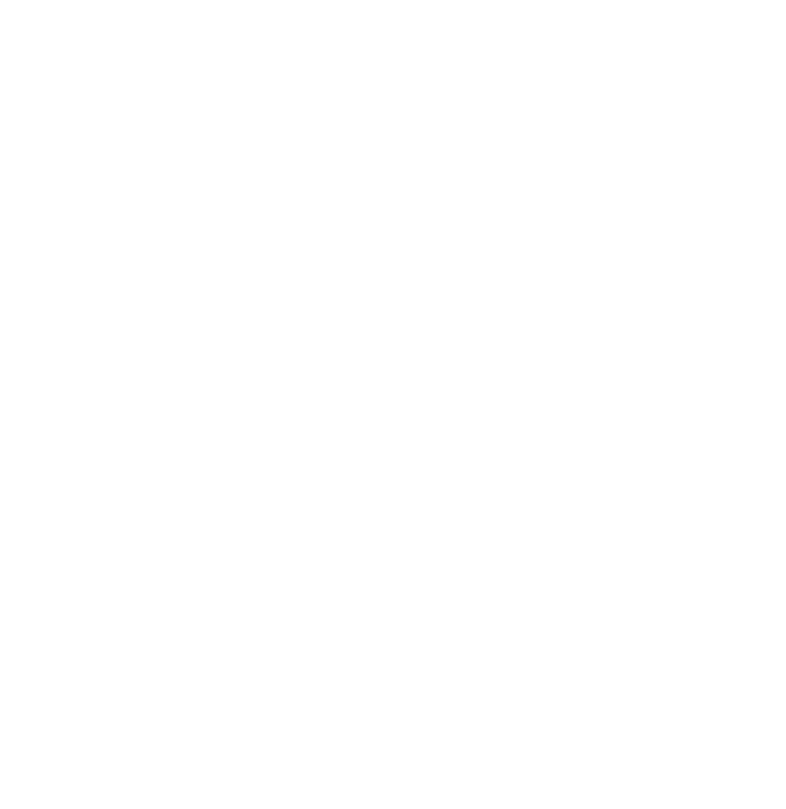

In [10]:
# Layout the widgets - vertical stack for sliders
controls = VBox([
    Label('━━━ Principal Basis (Orthonormal Frame) ━━━'),
    theta_widget,
    Label('━━━ Log Loadings ━━━'),
    log_s1_widget,
    log_s2_widget,
    Label('━━━ Rotation Coefficients β ━━━'),
    symmetry_toggle,
    beta_11_widget,
    beta_12_widget,
    beta_21_widget,  # Hidden by default when symmetry is enforced
    beta_22_widget,
    Label('━━━ Grid Settings ━━━'),
    span_widget,
    Label('━━━ Visualization ━━━'),
    show_grid_toggle,
    show_arrows_toggle,
    show_samples_toggle,
    sample_std_widget,   # Hidden by default, shown when samples enabled
    n_samples_widget,    # Hidden by default, shown when samples enabled
    update_button
])

# Display everything
display(HBox([controls, output]))

# Initial plot
update_plot()
